<a href="https://colab.research.google.com/github/ArkSen05-gh/My-portfolio/blob/main/Krutanic_ML_Work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost

Dataset shape: (569, 30)
Class distribution:
 1    357
0    212
Name: count, dtype: int64
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

  

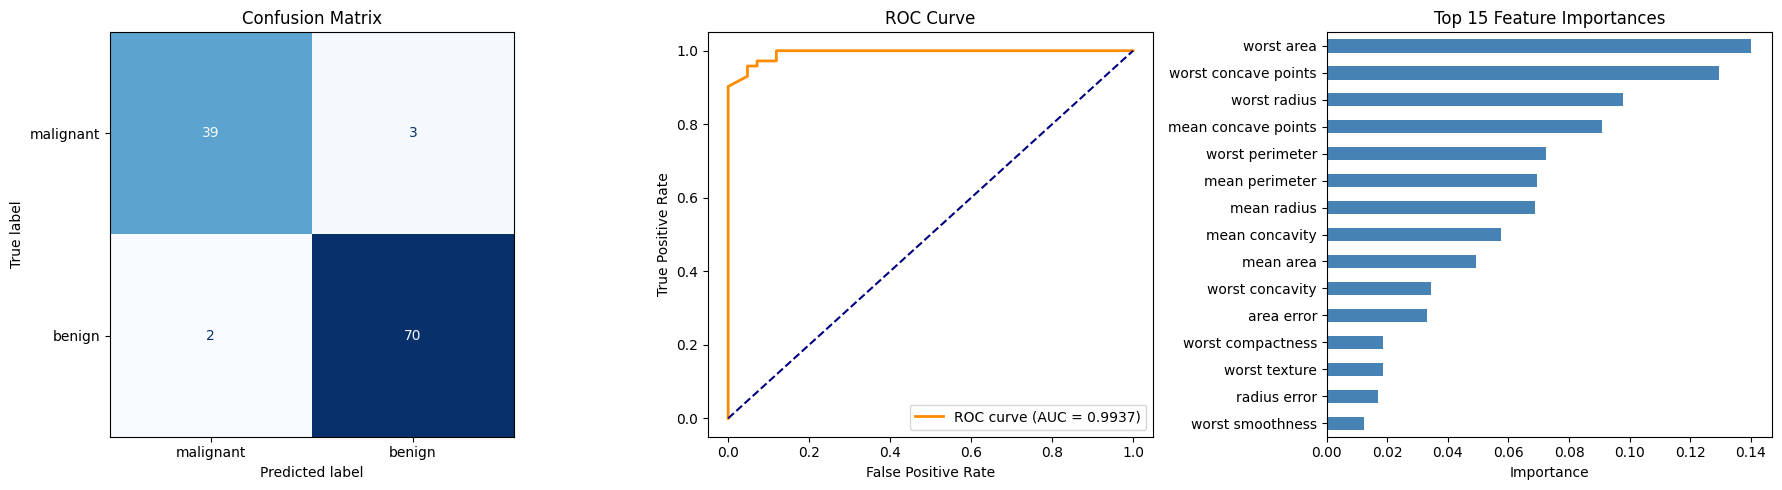


Plot saved as 'task1_random_forest_results.png'


In [ ]:
# Task 1: Random Forest Classifier - Breast Cancer Dataset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ── 1. Load Dataset ──────────────────────────────────────────
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)           # 0 = malignant, 1 = benign

print("Dataset shape:", X.shape)
print("Class distribution:\n", y.value_counts())
print(X.head())

# ── 2. Train / Test Split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ── 3. Train Random Forest ───────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# ── 4. Predictions ───────────────────────────────────────────
y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# ── 5. Evaluation ────────────────────────────────────────────
print("\n" + "="*50)
print("         MODEL EVALUATION - RANDOM FOREST")
print("="*50)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=data.target_names))

# ── 6. Confusion Matrix Plot ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# ── 7. ROC Curve ─────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color="darkorange", lw=2,
             label=f"ROC curve (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

# ── 8. Feature Importance (Top 15) ───────────────────────────
importances = pd.Series(rf_model.feature_importances_,
                        index=data.feature_names)
top15 = importances.nlargest(15)
top15.sort_values().plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Top 15 Feature Importances")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("task1_random_forest_results.png", dpi=150)
plt.show()
print("\nPlot saved as 'task1_random_forest_results.png'")

Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Zero counts in medical columns before replacement:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

After handling zeros:
       Glucose  BloodPressure  SkinThickness  Insulin     BMI
count   768.00         768.00   

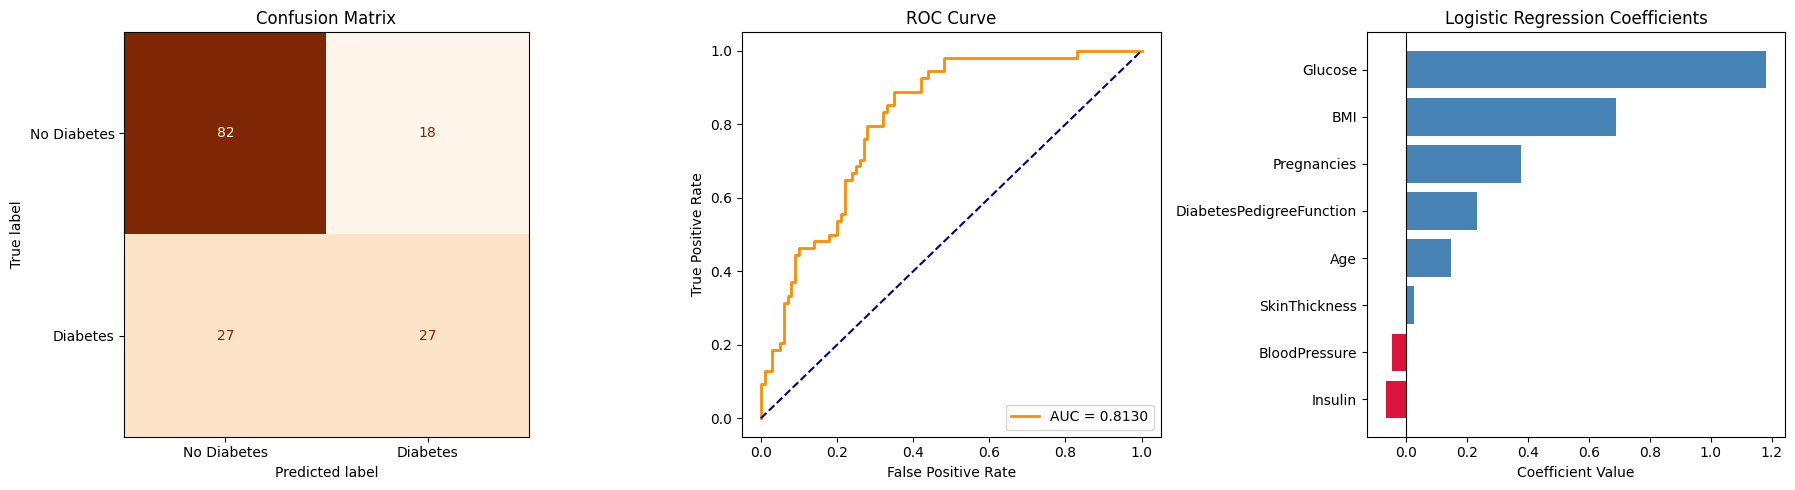


Plot saved as 'task2_logistic_regression_results.png'


In [ ]:
# Task 2: Logistic Regression - Diabetes Prediction
# ====================================================
# Dataset: Pima Indians Diabetes Dataset
# Source  : https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ── 1. Load Dataset ──────────────────────────────────────────
url = ("https://raw.githubusercontent.com/jbrownlee/Datasets/"
       "master/pima-indians-diabetes.data.csv")

column_names = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv(url, header=None, names=column_names)
print("Shape:", df.shape)
print(df.head())

# ── 2. Check Missing / Zero Values ───────────────────────────
zero_cols = ["Glucose", "BloodPressure", "SkinThickness",
             "Insulin", "BMI"]

print("\nZero counts in medical columns before replacement:")
print((df[zero_cols] == 0).sum())

# Replace zeros with column median (biologically impossible zeros)
for col in zero_cols:
    median_val = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, median_val)

print("\nAfter handling zeros:")
print(df[zero_cols].describe().round(2))
print("\nMissing values:", df.isnull().sum().sum())

# ── 3. Features & Target ─────────────────────────────────────
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("\nClass distribution:\n", y.value_counts())

# ── 4. Train / Test Split (80 / 20) ──────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ── 5. Feature Scaling ────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── 6. Train Logistic Regression ─────────────────────────────
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver="lbfgs"
)
lr_model.fit(X_train_sc, y_train)

# ── 7. Predictions ───────────────────────────────────────────
y_pred       = lr_model.predict(X_test_sc)
y_pred_proba = lr_model.predict_proba(X_test_sc)[:, 1]

# ── 8. Evaluation ────────────────────────────────────────────
print("\n" + "="*50)
print("      MODEL EVALUATION - LOGISTIC REGRESSION")
print("="*50)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["No Diabetes", "Diabetes"]))

# ── 9. Model Coefficients ────────────────────────────────────
coef_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Coefficient": lr_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

print("\nModel Coefficients (sorted by |magnitude|):")
print(coef_df.to_string(index=False))

# ── 10. Plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"]
                       ).plot(ax=axes[0], colorbar=False, cmap="Oranges")
axes[0].set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color="darkorange", lw=2,
             label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], "navy", linestyle="--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

# Coefficients
coef_df_plot = coef_df.sort_values("Coefficient")
colors = ["crimson" if c < 0 else "steelblue"
          for c in coef_df_plot["Coefficient"]]
axes[2].barh(coef_df_plot["Feature"], coef_df_plot["Coefficient"],
             color=colors)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title("Logistic Regression Coefficients")
axes[2].set_xlabel("Coefficient Value")

plt.tight_layout()
plt.savefig("task2_logistic_regression_results.png", dpi=150)
plt.show()
print("\nPlot saved as 'task2_logistic_regression_results.png'")

Raw shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Missing values before handling:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Missing values after ha

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:54:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



         MODEL EVALUATION - XGBOOST

Accuracy : 0.7933 (79.33%)
ROC-AUC  : 0.8275

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.80      0.89      0.84       110
       Survived       0.79      0.64      0.70        69

       accuracy                           0.79       179
      macro avg       0.79      0.76      0.77       179
   weighted avg       0.79      0.79      0.79       179


Feature Importances:
   Feature  Importance
       Sex    0.503664
    Pclass    0.145533
FamilySize    0.068614
      Fare    0.059150
       Age    0.058431
  Embarked    0.053910
     SibSp    0.045848
     Parch    0.039132
   IsAlone    0.025718


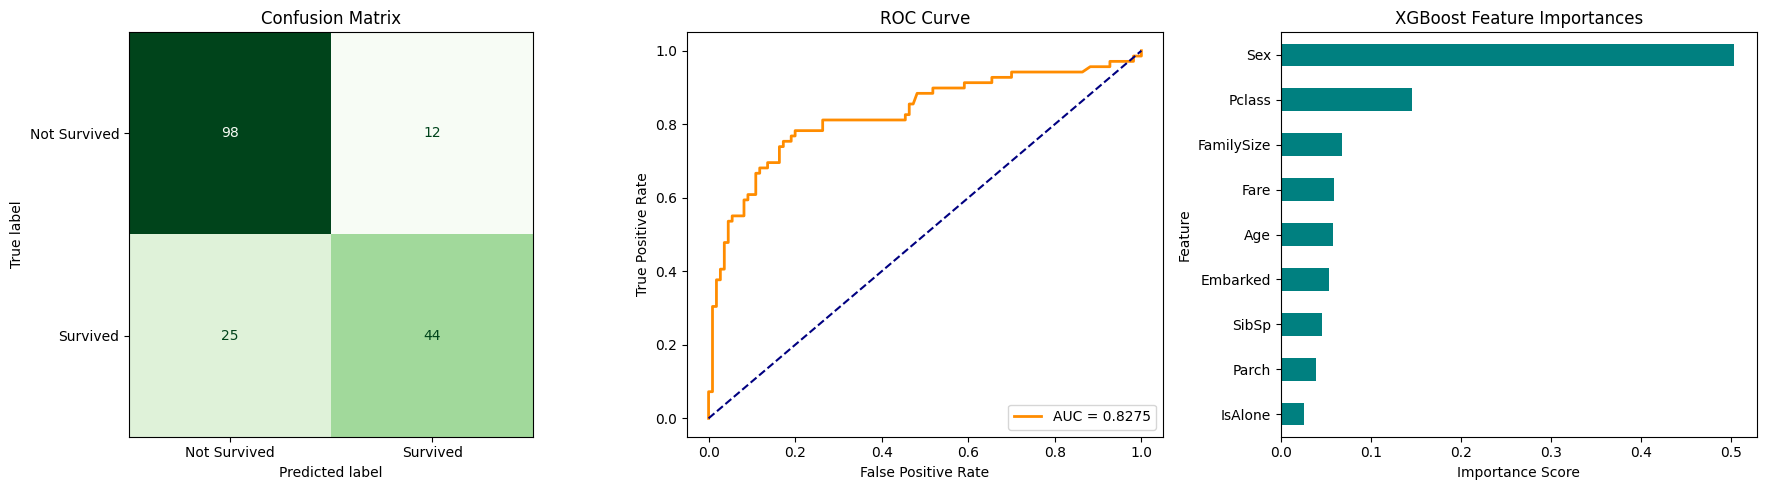


Plot saved as 'task3_xgboost_titanic_results.png'


In [ ]:
# Task 3: XGBoost Classifier - Titanic Survival Prediction
# ===========================================================
# Dataset: Titanic (via Seaborn / OpenML)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# ── 1. Load Dataset ──────────────────────────────────────────
df = sns.load_dataset("titanic")
print("Raw shape:", df.shape)
print(df.head())

# ── 2. Select & Rename Useful Columns ────────────────────────
df = df[["survived", "pclass", "sex", "age",
         "sibsp", "parch", "fare", "embarked"]].copy()

df.columns = ["Survived", "Pclass", "Sex", "Age",
              "SibSp", "Parch", "Fare", "Embarked"]

# ── 3. Handle Missing Values ─────────────────────────────────
print("\nMissing values before handling:")
print(df.isnull().sum())

df["Age"]      = df["Age"].fillna(df["Age"].median())
df["Fare"]     = df["Fare"].fillna(df["Fare"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("\nMissing values after handling:", df.isnull().sum().sum())

# ── 4. Encode Categorical Features ───────────────────────────
le = LabelEncoder()
df["Sex"]      = le.fit_transform(df["Sex"])       # male=1, female=0
df["Embarked"] = le.fit_transform(df["Embarked"]) # C=0, Q=1, S=2

print("\nSample after encoding:")
print(df.head())

# ── 5. Feature Engineering ───────────────────────────────────
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"]    = (df["FamilySize"] == 1).astype(int)

# ── 6. Features & Target ─────────────────────────────────────
feature_cols = ["Pclass", "Sex", "Age", "SibSp", "Parch",
                "Fare", "Embarked", "FamilySize", "IsAlone"]
X = df[feature_cols]
y = df["Survived"]

print("\nClass distribution:\n", y.value_counts())

# ── 7. Train / Test Split (80 / 20) ──────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ── 8. Feature Scaling ────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── 9. Train XGBoost ─────────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators     = 200,
    learning_rate    = 0.05,
    max_depth        = 4,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    use_label_encoder= False,
    eval_metric      = "logloss",
    random_state     = 42
)
xgb_model.fit(
    X_train_sc, y_train,
    eval_set=[(X_test_sc, y_test)],
    verbose=False
)

# ── 10. Predictions ──────────────────────────────────────────
y_pred       = xgb_model.predict(X_test_sc)
y_pred_proba = xgb_model.predict_proba(X_test_sc)[:, 1]

# ── 11. Evaluation ───────────────────────────────────────────
print("\n" + "="*50)
print("         MODEL EVALUATION - XGBOOST")
print("="*50)

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_proba)
print(f"\nAccuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["Did Not Survive", "Survived"]))

# ── 12. Feature Importances ──────────────────────────────────
importance_df = pd.DataFrame({
    "Feature"   : feature_cols,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importances:")
print(importance_df.to_string(index=False))

# ── 13. Plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Survived", "Survived"]
                       ).plot(ax=axes[0], colorbar=False, cmap="Greens")
axes[0].set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color="darkorange", lw=2,
             label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], "navy", linestyle="--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

# Feature Importance
importance_df.sort_values("Importance").plot(
    kind="barh", x="Feature", y="Importance",
    ax=axes[2], color="teal", legend=False
)
axes[2].set_title("XGBoost Feature Importances")
axes[2].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("task3_xgboost_titanic_results.png", dpi=150)
plt.show()
print("\nPlot saved as 'task3_xgboost_titanic_results.png'")

Dataset shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Zero counts in medical columns:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
  Glucose: zeros replaced with median = 117.00
  BloodPressure: zeros replaced with median = 72.00
  SkinThickness: zeros replac

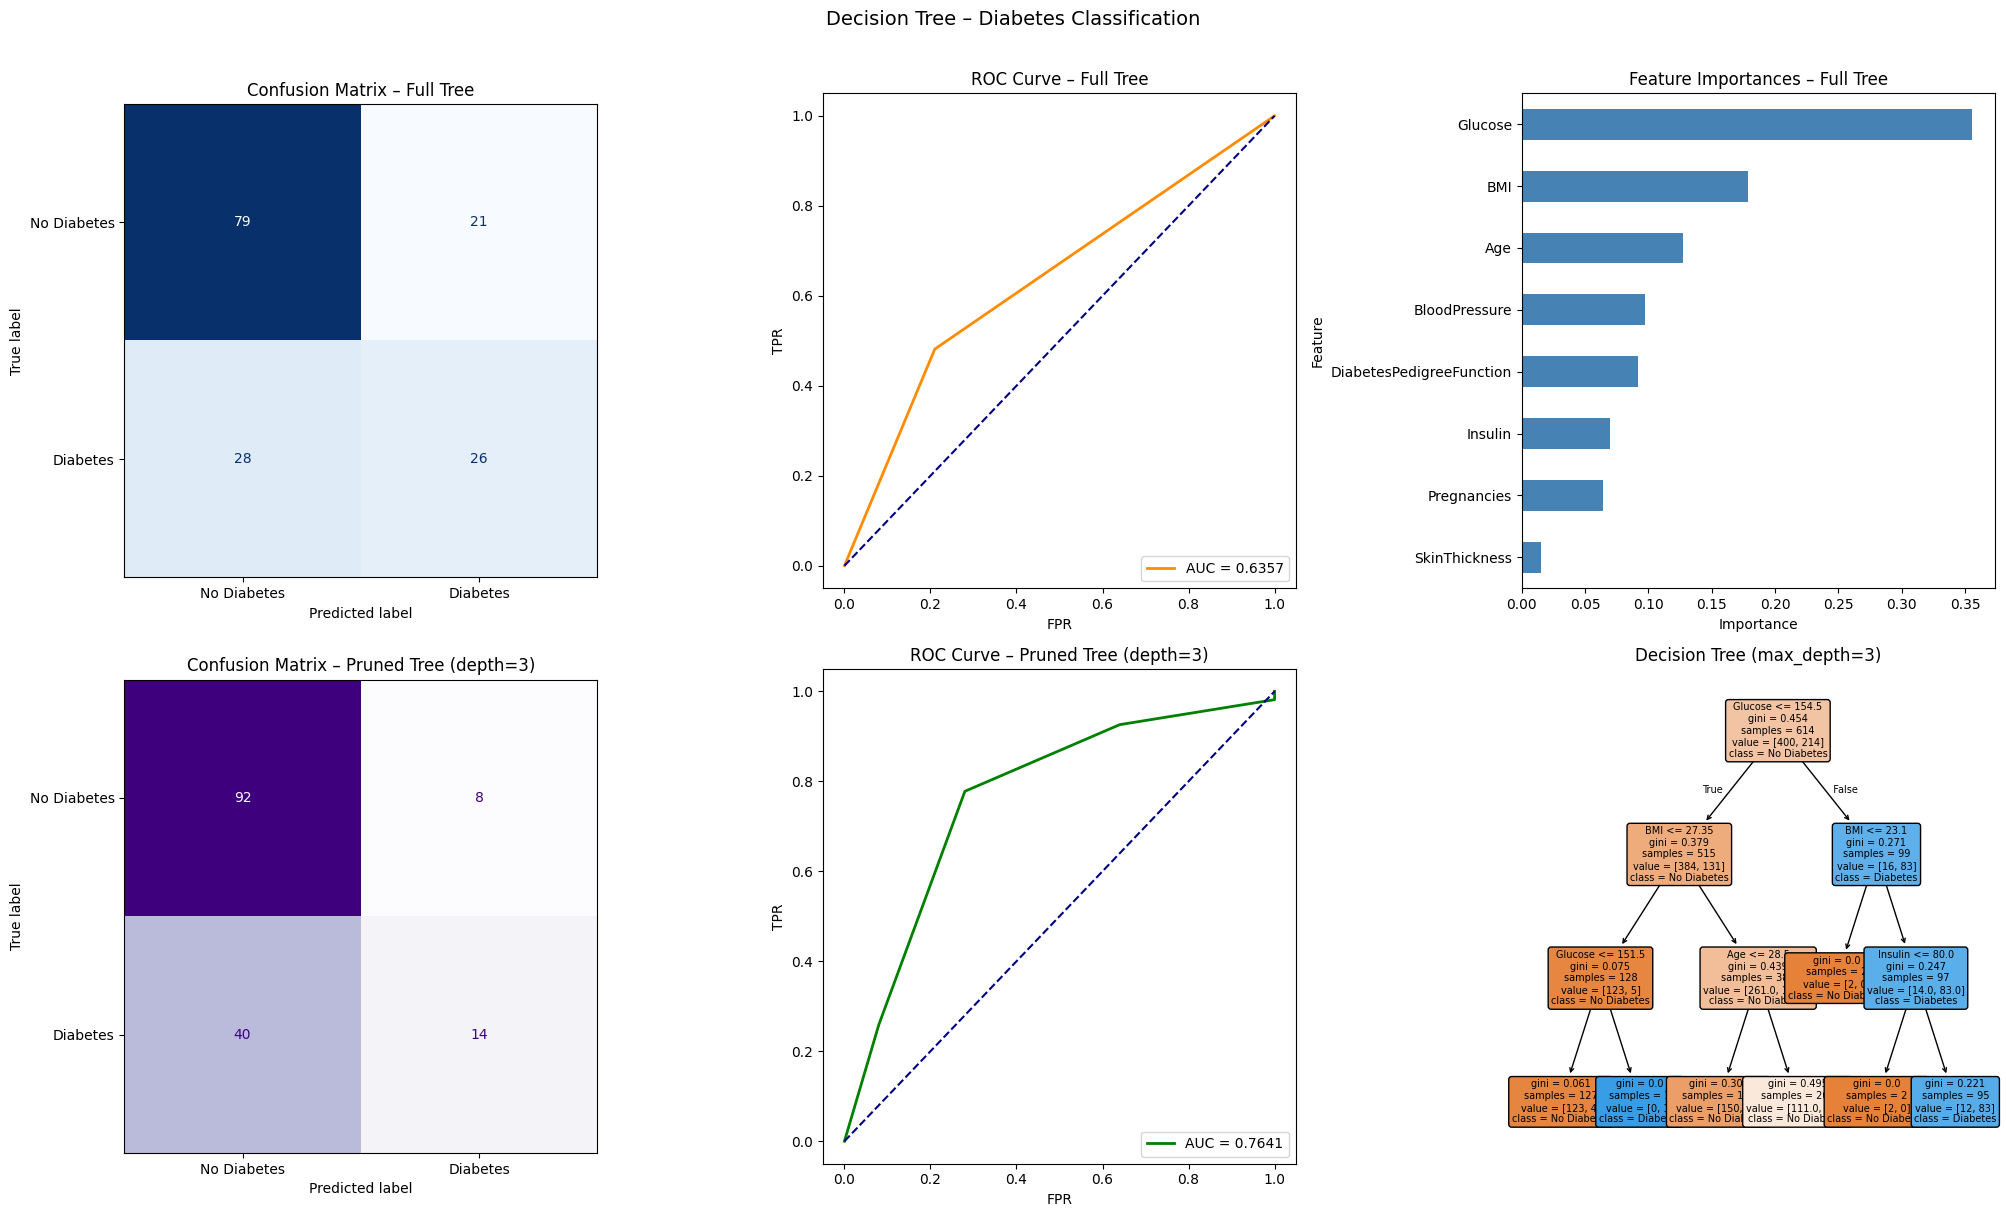


Plot saved as 'task4_decision_tree_diabetes_results.png'

Decision Rules (Pruned Tree, depth=3):
|--- Glucose <= 154.50
|   |--- BMI <= 27.35
|   |   |--- Glucose <= 151.50
|   |   |   |--- class: 0
|   |   |--- Glucose >  151.50
|   |   |   |--- class: 1
|   |--- BMI >  27.35
|   |   |--- Age <= 28.50
|   |   |   |--- class: 0
|   |   |--- Age >  28.50
|   |   |   |--- class: 0
|--- Glucose >  154.50
|   |--- BMI <= 23.10
|   |   |--- class: 0
|   |--- BMI >  23.10
|   |   |--- Insulin <= 80.00
|   |   |   |--- class: 0
|   |   |--- Insulin >  80.00
|   |   |   |--- class: 1



In [ ]:
# Task 4: Decision Tree Classifier - Pima Indians Diabetes Dataset
# ==================================================================
# 0 = No Diabetes, 1 = Diabetes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import (DecisionTreeClassifier,
                          plot_tree, export_text)
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ── 1. Load Dataset ──────────────────────────────────────────
url = ("https://raw.githubusercontent.com/jbrownlee/Datasets/"
       "master/pima-indians-diabetes.data.csv")

column_names = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv(url, header=None, names=column_names)
print("Dataset shape:", df.shape)
print(df.head())

# ── 2. Check Missing / Unrealistic Zero Values ───────────────
zero_cols = ["Glucose", "BloodPressure", "SkinThickness",
             "Insulin", "BMI"]

print("\nZero counts in medical columns:")
print((df[zero_cols] == 0).sum())

# Replace biologically impossible zeros with column median
for col in zero_cols:
    median_val = df[col].replace(0, np.nan).median()
    df[col]    = df[col].replace(0, median_val)
    print(f"  {col}: zeros replaced with median = {median_val:.2f}")

print("\nMissing values after handling:", df.isnull().sum().sum())
print("\nDescriptive stats:\n", df.describe().round(2))

# ── 3. Features & Target ─────────────────────────────────────
feature_cols = column_names[:-1]
X = df[feature_cols]
y = df["Outcome"]

print("\nClass distribution:\n", y.value_counts())

# ── 4. Train / Test Split (80 / 20, random_state=42) ─────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")

# ══════════════════════════════════════════════════════════════
# MODEL A: Full Decision Tree (no depth restriction)
# ══════════════════════════════════════════════════════════════
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

y_pred_full  = dt_full.predict(X_test)
y_prob_full  = dt_full.predict_proba(X_test)[:, 1]

acc_full = accuracy_score(y_test, y_pred_full)
auc_full = roc_auc_score(y_test, y_prob_full)

print("\n" + "="*55)
print("    MODEL A - Full Decision Tree (no depth limit)")
print("="*55)
print(f"Tree Depth  : {dt_full.get_depth()}")
print(f"Accuracy    : {acc_full:.4f} ({acc_full*100:.2f}%)")
print(f"ROC-AUC     : {auc_full:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_full,
                            target_names=["No Diabetes", "Diabetes"]))

# ══════════════════════════════════════════════════════════════
# MODEL B: Pruned Decision Tree (max_depth=3)
# ══════════════════════════════════════════════════════════════
dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)
y_prob_pruned = dt_pruned.predict_proba(X_test)[:, 1]

acc_pruned = accuracy_score(y_test, y_pred_pruned)
auc_pruned = roc_auc_score(y_test, y_prob_pruned)

print("\n" + "="*55)
print("    MODEL B - Pruned Decision Tree (max_depth=3)")
print("="*55)
print(f"Tree Depth  : {dt_pruned.get_depth()}")
print(f"Accuracy    : {acc_pruned:.4f} ({acc_pruned*100:.2f}%)")
print(f"ROC-AUC     : {auc_pruned:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pruned,
                            target_names=["No Diabetes", "Diabetes"]))

# ── 5. Performance Comparison ────────────────────────────────
comparison = pd.DataFrame({
    "Model"   : ["Full Tree", "Pruned Tree (depth=3)"],
    "Depth"   : [dt_full.get_depth(), dt_pruned.get_depth()],
    "Accuracy": [acc_full, acc_pruned],
    "ROC-AUC" : [auc_full, auc_pruned]
})
print("\nPerformance Comparison:")
print(comparison.to_string(index=False))

# ── 6. Feature Importance (Full Tree) ────────────────────────
fi_df = pd.DataFrame({
    "Feature"   : feature_cols,
    "Importance": dt_full.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importances (Full Tree):")
print(fi_df.to_string(index=False))

# ── 7. Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# --- Row 1: Full Tree ---
cm_full = confusion_matrix(y_test, y_pred_full)
ConfusionMatrixDisplay(cm_full,
    display_labels=["No Diabetes", "Diabetes"]
).plot(ax=axes[0, 0], colorbar=False, cmap="Blues")
axes[0, 0].set_title("Confusion Matrix – Full Tree")

fpr_f, tpr_f, _ = roc_curve(y_test, y_prob_full)
axes[0, 1].plot(fpr_f, tpr_f, color="darkorange", lw=2,
                label=f"AUC = {auc_full:.4f}")
axes[0, 1].plot([0, 1], [0, 1], "navy", linestyle="--")
axes[0, 1].set(xlabel="FPR", ylabel="TPR",
               title="ROC Curve – Full Tree")
axes[0, 1].legend(loc="lower right")

fi_df.sort_values("Importance").plot(
    kind="barh", x="Feature", y="Importance",
    ax=axes[0, 2], color="steelblue", legend=False
)
axes[0, 2].set_title("Feature Importances – Full Tree")
axes[0, 2].set_xlabel("Importance")

# --- Row 2: Pruned Tree ---
cm_p = confusion_matrix(y_test, y_pred_pruned)
ConfusionMatrixDisplay(cm_p,
    display_labels=["No Diabetes", "Diabetes"]
).plot(ax=axes[1, 0], colorbar=False, cmap="Purples")
axes[1, 0].set_title("Confusion Matrix – Pruned Tree (depth=3)")

fpr_p, tpr_p, _ = roc_curve(y_test, y_prob_pruned)
axes[1, 1].plot(fpr_p, tpr_p, color="green", lw=2,
                label=f"AUC = {auc_pruned:.4f}")
axes[1, 1].plot([0, 1], [0, 1], "navy", linestyle="--")
axes[1, 1].set(xlabel="FPR", ylabel="TPR",
               title="ROC Curve – Pruned Tree (depth=3)")
axes[1, 1].legend(loc="lower right")

# Pruned Tree visualized
plot_tree(
    dt_pruned,
    feature_names=feature_cols,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    ax=axes[1, 2],
    fontsize=7
)
axes[1, 2].set_title("Decision Tree (max_depth=3)")

plt.suptitle("Decision Tree – Diabetes Classification", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("task4_decision_tree_diabetes_results.png", dpi=150)
plt.show()
print("\nPlot saved as 'task4_decision_tree_diabetes_results.png'")

# ── 8. Pruned Tree Text Rules ────────────────────────────────
print("\nDecision Rules (Pruned Tree, depth=3):")
print(export_text(dt_pruned, feature_names=feature_cols))